# Análise Exploratória de Dados (EDA) - CPRE


## 1. Importação de Bibliotecas e Leitura dos Dados
Nesta secção, carregamos o ficheiro `metadata.csv` e filtramos apenas as imagens marcadas com `Keep`.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import os

# Caminho para o ficheiro metadata
metadata_path = '../data/metadata.csv'

# Ler os dados
df = pd.read_csv(metadata_path)

# Filtrar apenas as imagens que são para manter ("Keep")
df_keep = df[df['Keep'] == 'Keep'].copy()

print(f"Total de imagens no dataset: {len(df)}")
print(f"Total de imagens para manter: {len(df_keep)}")
display(df_keep.head())


Total de imagens no dataset: 19317
Total de imagens para manter: 15216


,raw_image_path,processed_image_path,patient_id,image_type,sex,birth_date,exam_date,exam_time,age,equipment_model,Label,Keep
0,raw/1_image1.png,processed/1_image1.png,1,S,M,22/08/1952,03/02/2022,11:50:32,69.0,Ziehm Vision RFD,Unlabelled,Keep
1,raw/1_image2.png,processed/1_image2.png,1,S,M,22/08/1952,03/02/2022,11:47:43,69.0,Ziehm Vision RFD,Unlabelled,Keep
2,raw/1_image3.png,processed/1_image3.png,1,S,M,22/08/1952,03/02/2022,12:08:45,69.0,Ziehm Vision RFD,Unlabelled,Keep
3,raw/1_image4.png,processed/1_image4.png,1,S,M,22/08/1952,03/02/2022,11:50:22,69.0,Ziehm Vision RFD,Unlabelled,Keep
11,raw/3_image12.png,processed/3_image12.png,3,S,M,12/03/1972,27/01/2022,13:07:58,49.0,Ziehm Vision RFD,Unlabelled,Keep


## 2. Limpeza e Agrupamento de Classes
Agrupamos as 'Strictures', removemos as imagens não rotuladas e mantemos apenas as 4 classes principais.

In [14]:
# Agrupar Malignant e Benign Stricture na classe 'Stricture'
df_keep['Label'] = df_keep['Label'].replace({
    'Malignant Stricture': 'Stricture',
    'Benign Stricture': 'Stricture'
})

# Remover as imagens que estão 'Unlabelled'
df_clean = df_keep[df_keep['Label'] != 'Unlabelled'].copy()

print("Distribuição das 4 classes principais:")
display(df_clean['Label'].value_counts())


Distribuição das 4 classes principais:


Label
Lithiasis        726
Stricture        392
Normal           299
Biliary Leaks    151
Name: count, dtype: int64

## 3. Análise Estatística (Gráfico da Distribuição)
Visualização do desequilíbrio das classes.

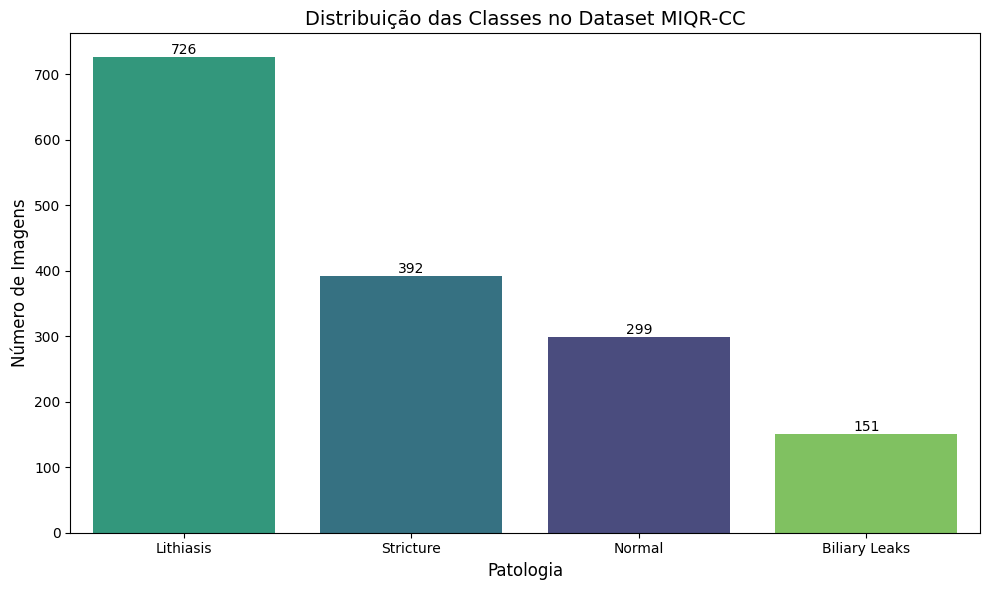

In [15]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='Label', order=df_clean['Label'].value_counts().index, hue='Label', palette='viridis', legend=False)
plt.title('Distribuição das Classes no Dataset MIQR-CC', fontsize=14)
plt.xlabel('Patologia', fontsize=12)
plt.ylabel('Número de Imagens', fontsize=12)

# Adicionar o número exato em cima de cada barra
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


## 4. Split de Dados (Treino, Validação e Teste)
Divisão com Estratificação (usando a proporção de Treino/Val/Teste e o Patient_id para evitar Data Leakage).

In [16]:
from sklearn.model_selection import train_test_split
import os

# 1. Definir proporções e calcular o combo dominante por doente
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15
RANDOM_STATE = 42

combo_counts = df_clean.groupby(['patient_id', 'Label', 'image_type']).size().reset_index(name='count')
patient_df = combo_counts.sort_values(['patient_id', 'count'], ascending=[True, False]).drop_duplicates('patient_id').reset_index(drop=True)
patient_df['combo'] = patient_df['Label'].astype(str) + '__' + patient_df['image_type'].astype(str)

# 2. Split doentes: Treino vs Resto
try:
    train_patients, temp_patients = train_test_split(patient_df, test_size=(1 - TRAIN_RATIO), stratify=patient_df['combo'], random_state=RANDOM_STATE)
except ValueError:
    train_patients, temp_patients = train_test_split(patient_df, test_size=(1 - TRAIN_RATIO), stratify=patient_df['Label'], random_state=RANDOM_STATE)

# 3. Split doentes: Validação vs Teste
try:
    val_patients, test_patients = train_test_split(temp_patients, test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO), stratify=temp_patients['combo'], random_state=RANDOM_STATE)
except ValueError:
    val_patients, test_patients = train_test_split(temp_patients, test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO), stratify=temp_patients['Label'], random_state=RANDOM_STATE)

print(f"Doentes: Treino: {len(train_patients)} | Validação: {len(val_patients)} | Teste: {len(test_patients)}")

# 4. Mapear de volta para as imagens
splits = {
    'train': set(train_patients['patient_id']),
    'val': set(val_patients['patient_id']),
    'test': set(test_patients['patient_id'])
}

def patient_split(pid):
    for s, patients in splits.items():
        if pid in patients:
            return s
    return None

df_clean['split'] = df_clean['patient_id'].apply(patient_split)

df_train = df_clean[df_clean['split'] == 'train'].copy()
df_val = df_clean[df_clean['split'] == 'val'].copy()
df_test = df_clean[df_clean['split'] == 'test'].copy()

print(f"\nImagens: Treino: {len(df_train)} | Validação: {len(df_val)} | Teste: {len(df_test)}")

# 5. Guardar os CSVs
os.makedirs('../data/processed', exist_ok=True)
df_train.to_csv('../data/processed/train_split.csv', index=False)
df_val.to_csv('../data/processed/val_split.csv', index=False)
df_test.to_csv('../data/processed/test_split.csv', index=False)
print("\nFicheiros CSV criados com sucesso na pasta 'data/processed'.")


Doentes: Treino: 305 | Validação: 65 | Teste: 66

Imagens: Treino: 1067 | Validação: 234 | Teste: 267

Ficheiros CSV criados com sucesso na pasta 'data/processed'.


### 4.4 Verificação de Qualidade (Sanity Checks) e Gráficos do Split
Tal como o professor fez, vamos garantir que não há pacientes a cruzar entre os sets de treino e validação (data leakage) e visualizar as distribuições de forma profissional.

✅ SUCESSO: Zero pacientes sobrepostos. Data leakage evitado com sucesso!

Distribuição exata por Label em cada sub-set:

--- TRAIN ---
Label
Lithiasis        505
Stricture        255
Normal           197
Biliary Leaks    110
Name: count, dtype: int64

--- VAL ---
Label
Lithiasis        98
Normal           59
Stricture        53
Biliary Leaks    24
Name: count, dtype: int64

--- TEST ---
Label
Lithiasis        123
Stricture         84
Normal            43
Biliary Leaks     17
Name: count, dtype: int64


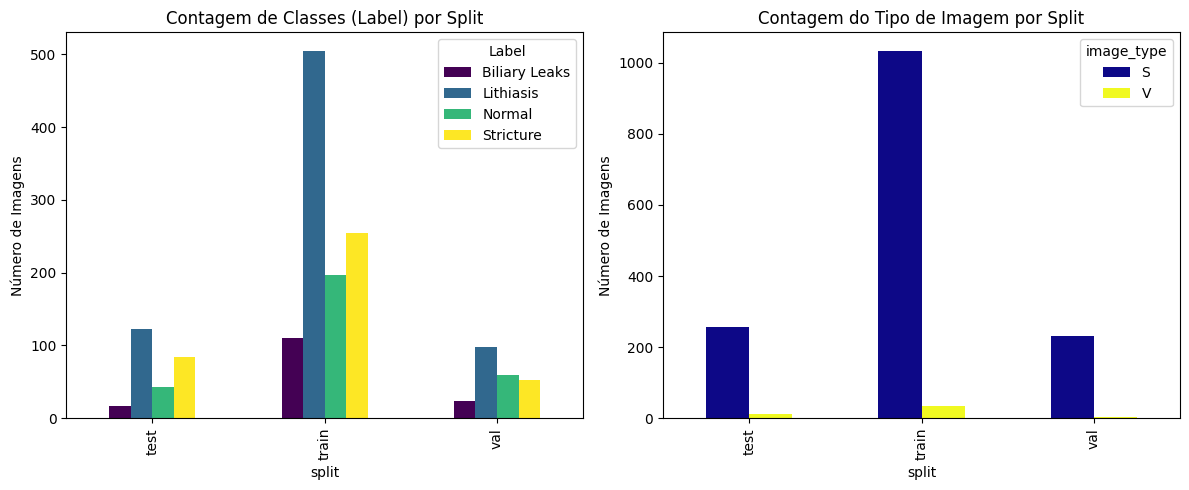

In [ ]:
overlaps = (
    len(set(train_patients['patient_id']) & set(val_patients['patient_id'])) +
    len(set(train_patients['patient_id']) & set(test_patients['patient_id'])) +
    len(set(val_patients['patient_id']) & set(test_patients['patient_id']))
)
if overlaps > 0:
    print(f"AVISO: {overlaps} pacientes sobrepostos entre os splits! (Fuga de Dados)")
else:
    print("SUCESSO: Zero pacientes sobrepostos. Data leakage evitado com sucesso!")

print('\nDistribuição exata por Label em cada sub-set:')
for split_name in ['train', 'val', 'test']:
    subset_df = df_clean[df_clean['split'] == split_name]
    print(f"\n--- {split_name.upper()} ---")
    print(subset_df['Label'].value_counts())

# Gráficos de barras lado-a-lado para as classes e tipo de imagem
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

label_counts = df_clean.groupby('split')['Label'].value_counts().unstack(fill_value=0)
label_counts.plot(kind='bar', stacked=False, ax=axes[0], colormap='viridis')
axes[0].set_title('Contagem de Classes (Label) por Split')
axes[0].set_ylabel('Número de Imagens')

itype_counts = df_clean.groupby('split')['image_type'].value_counts().unstack(fill_value=0)
itype_counts.plot(kind='bar', stacked=False, ax=axes[1], colormap='plasma')
axes[1].set_title('Contagem do Tipo de Imagem por Split')
axes[1].set_ylabel('Número de Imagens')

plt.tight_layout()
plt.show()


## 5. Criação de Pastas e Cópia Fìsica das Imagens
Tal como recomendado pelo código base do professor, vamos criar uma árvore de diretorias (`train/Lithiasis`, `val/Normal`, etc.) e copiar os ficheiros processados para lá. Isto irá facilitar imenso o treino dos modelos usando a class `ImageFolder` do PyTorch.

In [ ]:
import shutil

# Função para remover caracteres estranhos dos nomes das classes
def sanitize_label(s):
    return "".join(c if str(c).isalnum() or c in "._-" else "_" for c in str(s).strip())

BASE_PATH = '../data' # Pasta onde tem as imagens 'processed' 
OUTPUT_BASE = '../data/dataset' # Pasta de destino que será criada

labels = sorted(df_clean['Label'].unique())
label_to_dir = {lbl: sanitize_label(lbl) for lbl in labels}

# 5.1 Criar as pastas
for split in ['train', 'val', 'test']:
    for label, dir_name in label_to_dir.items():
        out_dir = os.path.join(OUTPUT_BASE, split, dir_name)
        os.makedirs(out_dir, exist_ok=True)
        
print("Pastas criadas com sucesso!")

# 5.2 Copiar as imagens
copied = 0
skipped = 0
missing = 0

for _, row in df_clean.iterrows():
    pid = row['patient_id']
    split = row.get('split')
    if not split:
        skipped += 1
        continue
        
    src = os.path.join(BASE_PATH, row['processed_image_path'])
    label_dir = label_to_dir.get(row['Label'], sanitize_label(row['Label']))
    
    # Nome final da imagem: ex: '1_image1.png'
    dst_name = f"{pid}_{os.path.basename(row['processed_image_path'])}"
    dst = os.path.join(OUTPUT_BASE, split, label_dir, dst_name)
    
    if os.path.exists(src):
        try:
            shutil.copy2(src, dst)
            copied += 1
        except Exception as e:
            print(f"Falha ao copiar {src} -> {dst}: {e}")
    else:
        missing += 1

print(f"Resumo da Cópia: {copied} copiadas, {missing} em falta, {skipped} ignoradas.")

Pastas criadas com sucesso!
Resumo da Cópia: 1568 copiadas, 0 em falta, 0 ignoradas.
